<a href="https://colab.research.google.com/github/hamidb201214-svg/Lectures/blob/main/Statistics_Lecture3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Chapter 4 statistics notebook using `Startupsin2020.csv`

This notebook uses the unicorn startup dataset to give **one practical example for each item** in the 4 sections below:

1. **Measure of Centrality**
   - Median
   - Mean
   - Mode

2. **Measure of Variability**
   - Range
   - Variance
   - Standard Deviation (SD)
   - Coefficient of Variation (CV)

3. **Relative Standing**
   - Percentile
   - Interquartile Range (IQR)

4. **Linear Relationship**
   - Covariance
   - Correlation Coefficient (CC or \(\rho\))
   - Coefficient of Determination (CD or \(r^2\))
   - Least Squares Method

**Dataset source**  
`https://raw.githubusercontent.com/hamidb201214-svg/Lectures/refs/heads/main/Startupsin2020.csv`


In [ ]:

import pandas as pd

# Load the dataset
url = "https://raw.githubusercontent.com/hamidb201214-svg/Lectures/refs/heads/main/Startupsin2020.csv"
data = pd.read_csv(url)


In [ ]:
data

,Company,Valuation ($B),Date Joined,Country,City,Industry,Select Investors
0,Bytedance,140,4/7/2017,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,100,12/1/2012,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,Stripe,95,1/23/2014,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG"
3,Klarna,45,12/12/2011,Sweden,Stockholm,Fintech,"Institutional Venture Partners, Sequoia Capita..."
4,Canva,40,1/8/2018,Australia,Surry Hills,Internet software & services,"Sequoia Capital China, Blackbird Ventures, Mat..."
...,...,...,...,...,...,...,...
931,YipitData,1,12/6/2021,United States,New York,Internet software & services,"RRE Ventures+, Highland Capital Partners, The ..."
932,Anyscale,1,12/7/2021,United States,Berkeley,Artificial Intelligence,"Andreessen Horowitz, Intel Capital, Foundation..."
933,Iodine Software,1,12/1/2021,United States,Austin,Data management & analytics,"Advent International, Bain Capital Ventures, S..."
934,ReliaQuest,1,12/1/2021,United States,Tampa,Cybersecurity,"KKR, FTV Capital, Ten Eleven Ventures"


## 1) Measure of Centrality

In [ ]:
data['Valuation ($B)'].mean()

np.float64(3.051282051282051)

In [ ]:
data['Valuation ($B)'].mode()

,Valuation ($B)
0,1


In [ ]:
data['Valuation ($B)'].median()

1.0


### Example interpretation
- **Mean** gives the average unicorn valuation.
- **Median** gives the middle valuation and is less affected by extreme firms like ByteDance or SpaceX.
- **Mode** gives the most common valuation in the dataset.


## 2) Measure of Variability

In [ ]:
data['Valuation ($B)'].max() - data['Valuation ($B)'].min()

139

In [ ]:
data['Valuation ($B)'].var(ddof=1)

55.926779103249864

In [ ]:
data['Valuation ($B)'].std(ddof=1) #delta degrees of freedom

7.47842089636909

In [ ]:
7.47842089636909 * 7.47842089636909

55.926779103249864

In [ ]:
# coefficient of variation = ratio * 100
(data['Valuation ($B)'].std(ddof=1) / data['Valuation ($B)'].mean()) * 100

np.float64(245.0911050070542)


### Example interpretation
- **Range** shows the overall spread from the smallest to largest valuation.
- **Variance** measures average squared spread around the mean.
- **Standard deviation** puts that spread back in the original unit: **billions of dollars**.
- **CV** shows relative variability, useful because it compares spread to the mean itself.


## 3) Relative Standing

In [ ]:
data['Valuation ($B)'].quantile(0.9)

np.float64(6.0)

In [ ]:
data['Valuation ($B)'].quantile(0.75) - data['Valuation ($B)'].quantile(0.25)

np.float64(2.0)

<Axes: >

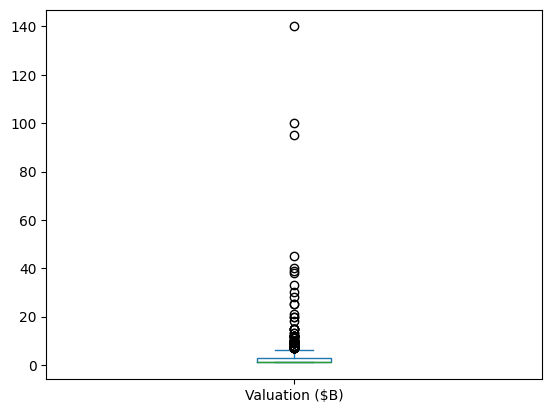

In [44]:
data['Valuation ($B)'].plot(kind='box')

### Bonus: Canva’s Valuation Ranking

In [ ]:
threshold = data[data["Company"] == "Canva"]['Valuation ($B)'].iloc[0]

In [ ]:
(data['Valuation ($B)'] <= threshold).mean() * 100

np.float64(0.9957264957264957)


### Example interpretation
- The **90th percentile** is the valuation level that about 90% of startups fall below.
- **IQR** measures the spread of the middle 50% of valuations and is less sensitive to outliers than the range.

- **Canva's percentile rank** tells us how its valuation compares with the rest of the dataset.


## 4) Linear Relationship


For the linear relationship section, we use:

- **X = Year Joined**
- **Y = Valuation ($B)**

This lets us examine whether more recently joined startups tend to have higher or lower valuations.


In [ ]:
import pandas as pd
import numpy as np

# Load the real Credit Card Default dataset directly from the public ISLR repository
url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/ISLR/Default.csv"
df = pd.read_csv(url)

In [ ]:
df

,rownames,default,student,balance,income
0,1,No,No,729.526495,44361.625074
1,2,No,Yes,817.180407,12106.134700
2,3,No,No,1073.549164,31767.138947
3,4,No,No,529.250605,35704.493935
4,5,No,No,785.655883,38463.495879
...,...,...,...,...,...
9995,9996,No,No,711.555020,52992.378914
9996,9997,No,No,757.962918,19660.721768
9997,9998,No,No,845.411989,58636.156984
9998,9999,No,No,1569.009053,36669.112365


In [ ]:
df['balance'].cov(df['income']) # May be difficulte to juge

np.float64(-982142.3355404867)

In [ ]:
df['income'].corr(df['balance']) # The drawback to CC is except for the three values (-1, 0, 1) we cannot interpret the correlation

np.float64(-0.1522434005860668)

In [ ]:
df['balance'].corr(df['income']) ** 2

np.float64(0.023178053022009606)

In [ ]:

# Plot the regression line
plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.6)
plt.plot(x, y_hat, linewidth=2)
plt.title("Valuation vs Year Joined with Least Squares Line")
plt.xlabel("Year Joined")
plt.ylabel("Valuation ($B)")
plt.show()



### Example interpretation
- **Covariance** shows whether the variables move together in the same or opposite direction.
- **Correlation coefficient (r)** standardizes the relationship to a value between -1 and 1.
- **Coefficient of determination (r²)** tells us the proportion of variation in valuation explained by year joined.
- **Least squares method** gives the best-fitting straight line for prediction.
